In [1]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import re

from scipy.interpolate import BSpline

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
n_paths_max = 10000
dt = 1.0  # one calendar-day step (used for OLS calibration only)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data and lift it onto a full calendar-day grid
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

spot_obs = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Build a daily calendar grid shared by spot and forwards
# ----------------------------
calendar_dates = pd.date_range(
    start=max(spot_obs["date"].min(), forward_curve["date"].min()),
    end=min(spot_obs["date"].max(), forward_curve["date"].max()),
    freq="D",
)

data = pd.DataFrame({"date": calendar_dates})
data = data.merge(spot_obs, on="date", how="left")
data["spot_price"] = data["spot_price"].ffill()
data = data.merge(forward_curve, on="date", how="left")

if data[["spot_price", "forward_price"]].isna().any().any():
    raise ValueError("Calendar-day grid contains missing spot or forward prices.")

# ----------------------------
# Joint estimation of seasonality + AR(1)  [calendar days]
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build price-process arrays on the calendar-day grid
# ----------------------------
data  = data.sort_values("date").reset_index(drop=True)
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# Transition from step i-1 to i spans h = t_arr[i] - t_arr[i-1] calendar days.
# On the daily calendar grid used here, h = 1 for ordinary steps, but the
# per-step formula is kept so the notebook remains robust to non-daily gaps.
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 10_000.0
refine_factor    = 4
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual                 = 0.1
basis_degree             = 3
spline_degree            = 3
n_spline_internal_knots  = 3
terminal_penalty         = -np.inf

# Step-varying discount on the calendar-day grid.
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 250_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 2_500.0
WDRMAX_BASE    = 7_500.0

# ---------- vmin: constant ----------
VMIN_CONST = 0.0

def inj_cap(fill_frac: float) -> float:
    return INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    return WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = np.full(len(dates_pd), VMIN_CONST, dtype=np.float64)

# v0 and vT_target
v0        = round(100_000.0 / alpha_f) * alpha_f
vT_target = round(100_000.0 / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}")
print(f"vT_target = {vT_target:>12,.0f}")
print(f"vmax: {VMAX_CONST:,.0f}")
print(f"vmin: {VMIN_CONST:,.0f}")

# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Rate caps are scaled by the number of calendar days in the step so that
    weekend/holiday gaps (e.g. Fri→Mon = 3 days) correctly allow 3× the
    daily injection/withdrawal capacity.
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right


@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty


@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next


def build_spline_knots_from_S(S_t: np.ndarray, n_internal_knots: int, degree: int):
    x = np.asarray(S_t, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size < degree + 2:
        return None
    x_unique = np.unique(x)
    if x_unique.size < degree + 2:
        return None

    q = np.linspace(0.0, 1.0, n_internal_knots + 2)[1:-1]
    interior = np.quantile(x_unique, q)
    xmin = float(x_unique[0])
    xmax = float(x_unique[-1])
    interior = interior[(interior > xmin) & (interior < xmax)]
    interior = np.unique(interior)
    if interior.size != n_internal_knots:
        return None

    return np.r_[np.repeat(xmin, degree + 1), interior, np.repeat(xmax, degree + 1)].astype(np.float64)


def build_poly_design_matrix(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    X = np.empty((x.size, 4), dtype=np.float64)
    X[:, 0] = 1.0
    X[:, 1] = x
    X[:, 2] = x * x
    X[:, 3] = X[:, 2] * x
    return X


def build_bspline_design_matrix(x: np.ndarray, full_knots: np.ndarray, degree: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    design = BSpline.design_matrix(x, full_knots, degree, extrapolate=True)
    return np.asarray(design.toarray(), dtype=np.float64)


@nb.njit(fastmath=True)
def accumulate_normal_eq_finite(X, y, XtX, XtY):
    p = X.shape[1]
    for a in range(p):
        XtY[a] = 0.0
        for b in range(p):
            XtX[a, b] = 0.0

    cnt = 0
    for i in range(X.shape[0]):
        yi = y[i]
        if np.isfinite(yi):
            cnt += 1
            for a in range(p):
                xa = X[i, a]
                XtY[a] += xa * yi
                for b in range(a, p):
                    XtX[a, b] += xa * X[i, b]

    for a in range(p):
        for b in range(a):
            XtX[a, b] = XtX[b, a]
    return cnt


def fit_spline_coarse(X_poly, X_spline, Y_disc, reach_next, coarse_fine_idx,
                     spline_coef_t, poly_coef_t, fit_kind_t):
    n_basis = spline_coef_t.shape[0]
    use_spline = X_spline is not None
    Nc = coarse_fine_idx.size
    XtX_spline = np.empty((n_basis, n_basis), dtype=np.float64)
    XtY_spline = np.empty(n_basis, dtype=np.float64)
    XtX_poly = np.empty((4, 4), dtype=np.float64)
    XtY_poly = np.empty(4, dtype=np.float64)

    for j in range(Nc):
        if not reach_next[coarse_fine_idx[j]]:
            continue
        y = Y_disc[:, j]
        cnt = int(np.isfinite(y).sum())
        if cnt < 4:
            continue

        if use_spline and cnt >= n_basis:
            try:
                accumulate_normal_eq_finite(X_spline, y, XtX_spline, XtY_spline)
                coef = np.linalg.solve(XtX_spline, XtY_spline)
                spline_coef_t[:, j] = coef
                fit_kind_t[j] = 1
                continue
            except np.linalg.LinAlgError:
                pass

        try:
            accumulate_normal_eq_finite(X_poly, y, XtX_poly, XtY_poly)
            poly_coef_t[:, j] = np.linalg.solve(XtX_poly, XtY_poly)
            fit_kind_t[j] = 0
        except np.linalg.LinAlgError:
            continue


def evaluate_coarse_continuation(S_t, poly_coef_t, spline_coef_t, fit_kind_t,
                                full_knots, spline_degree):
    X_poly = build_poly_design_matrix(S_t)
    C_hat_coarse = X_poly @ poly_coef_t
    if full_knots is not None:
        spline_cols = (fit_kind_t == 1)
        if np.any(spline_cols):
            X_spline = build_bspline_design_matrix(S_t, full_knots, spline_degree)
            C_hat_coarse[:, spline_cols] = X_spline @ spline_coef_t[:, spline_cols]
    return X_poly, C_hat_coarse


@nb.njit(parallel=True, fastmath=True)
def forward_step_numba(n_curr, n_next, S_t, C_hat_fine_buf,
                       next_idx_mat, dv_mat, K_len, terminal_penalty):
    Mloc = S_t.shape[0]
    for i in nb.prange(Mloc):
        n    = n_curr[i]
        klen = K_len[n]
        s    = S_t[i]
        best_val  = terminal_penalty
        best_next = -1
        for kk in range(klen):
            nxt = next_idx_mat[n, kk]
            dv  = dv_mat[n, kk]
            cand = (-s * dv) + C_hat_fine_buf[i, nxt]
            if cand > best_val:
                best_val  = cand
                best_next = nxt
        n_next[i] = best_next if best_next != -1 else n


# ============================================================
# LSMC main function
# ============================================================
def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)

    # ---- Terminal condition ----
    tv        = terminal_value(v_fine)
    Y_next    = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    poly_dim    = basis_degree + 1
    spline_dim  = n_spline_internal_knots + spline_degree + 1
    knot_dim    = n_spline_internal_knots + 2 * (spline_degree + 1)
    knot_store        = np.empty((T, knot_dim), dtype=np.float64)
    spline_coef_store = np.zeros((T, spline_dim, Nc), dtype=np.float64)
    poly_coef_store   = np.zeros((T, poly_dim, Nc), dtype=np.float64)
    fit_kind_store    = np.zeros((T, Nc), dtype=np.int8)

    # ---- Backward pass ----
    for t in tqdm(range(T - 1, -1, -1), desc="Backward pass"):
        S_t = S[t].astype(np.float64, copy=False)

        X_poly = build_poly_design_matrix(S_t)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        full_knots = build_spline_knots_from_S(S_t, n_spline_internal_knots, spline_degree)
        if full_knots is None:
            knot_store[t].fill(np.nan)
        else:
            knot_store[t] = full_knots

        X_spline = None if full_knots is None else build_bspline_design_matrix(S_t, full_knots, spline_degree)
        fit_spline_coarse(
            X_poly, X_spline, Y_disc, reach_next, coarse_fine_idx,
            spline_coef_store[t], poly_coef_store[t], fit_kind_store[t]
        )

        C_hat_coarse = X_poly @ poly_coef_store[t]
        spline_cols = (fit_kind_store[t] == 1)
        if X_spline is not None and np.any(spline_cols):
            C_hat_coarse[:, spline_cols] = X_spline @ spline_coef_store[t][:, spline_cols]
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))

    # ---- Forward rollout ----
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    n_path_idx[0] = n0_f
    n_curr_forward = np.full(M, n0_f, dtype=np.int32)
    n_next_forward = np.empty(M, dtype=np.int32)
    for t in range(T):
        full_knots = None if np.isnan(knot_store[t, 0]) else knot_store[t]
        _, C_hat_coarse = evaluate_coarse_continuation(
            S[t], poly_coef_store[t], spline_coef_store[t], fit_kind_store[t],
            full_knots, spline_degree
        )
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, all_can_reach[t + 1], terminal_penalty)
        forward_step_numba(
            n_curr_forward, n_next_forward, S[t], C_hat_fine_buf,
            all_next_idx[t], all_dv_mat[t], all_K_len[t], terminal_penalty
        )
        n_path_idx[t + 1] = n_next_forward
        n_curr_forward, n_next_forward = n_next_forward, n_curr_forward

    v_path = v_fine[n_path_idx]
    spline_store = {
        "knot_store": knot_store,
        "spline_coef_store": spline_coef_store,
        "poly_coef_store": poly_coef_store,
        "fit_kind_store": fit_kind_store,
        "degree": spline_degree,
    }
    return V0_hat, v_path, data["date"].to_numpy(), spline_store

# ============================================================
# Run once: simulate S, value, then plot inventory band
# ============================================================
S_sim = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)
V0_hat, v_path, dates, spline_store = lsmc_value_and_paths_given_S(S_sim)
print("V0_hat =", V0_hat)


v0        =      100,000
vT_target =      100,000
vmax: 250,000
vmin: 0

Grid: Nc=26, Nf=101, n0_f=40, nT_f=40
Pre-computing feasible action sets …
Done.


Backward pass: 100%|██████████| 729/729 [00:06<00:00, 121.42it/s]


V0_hat = 3343001.701657048


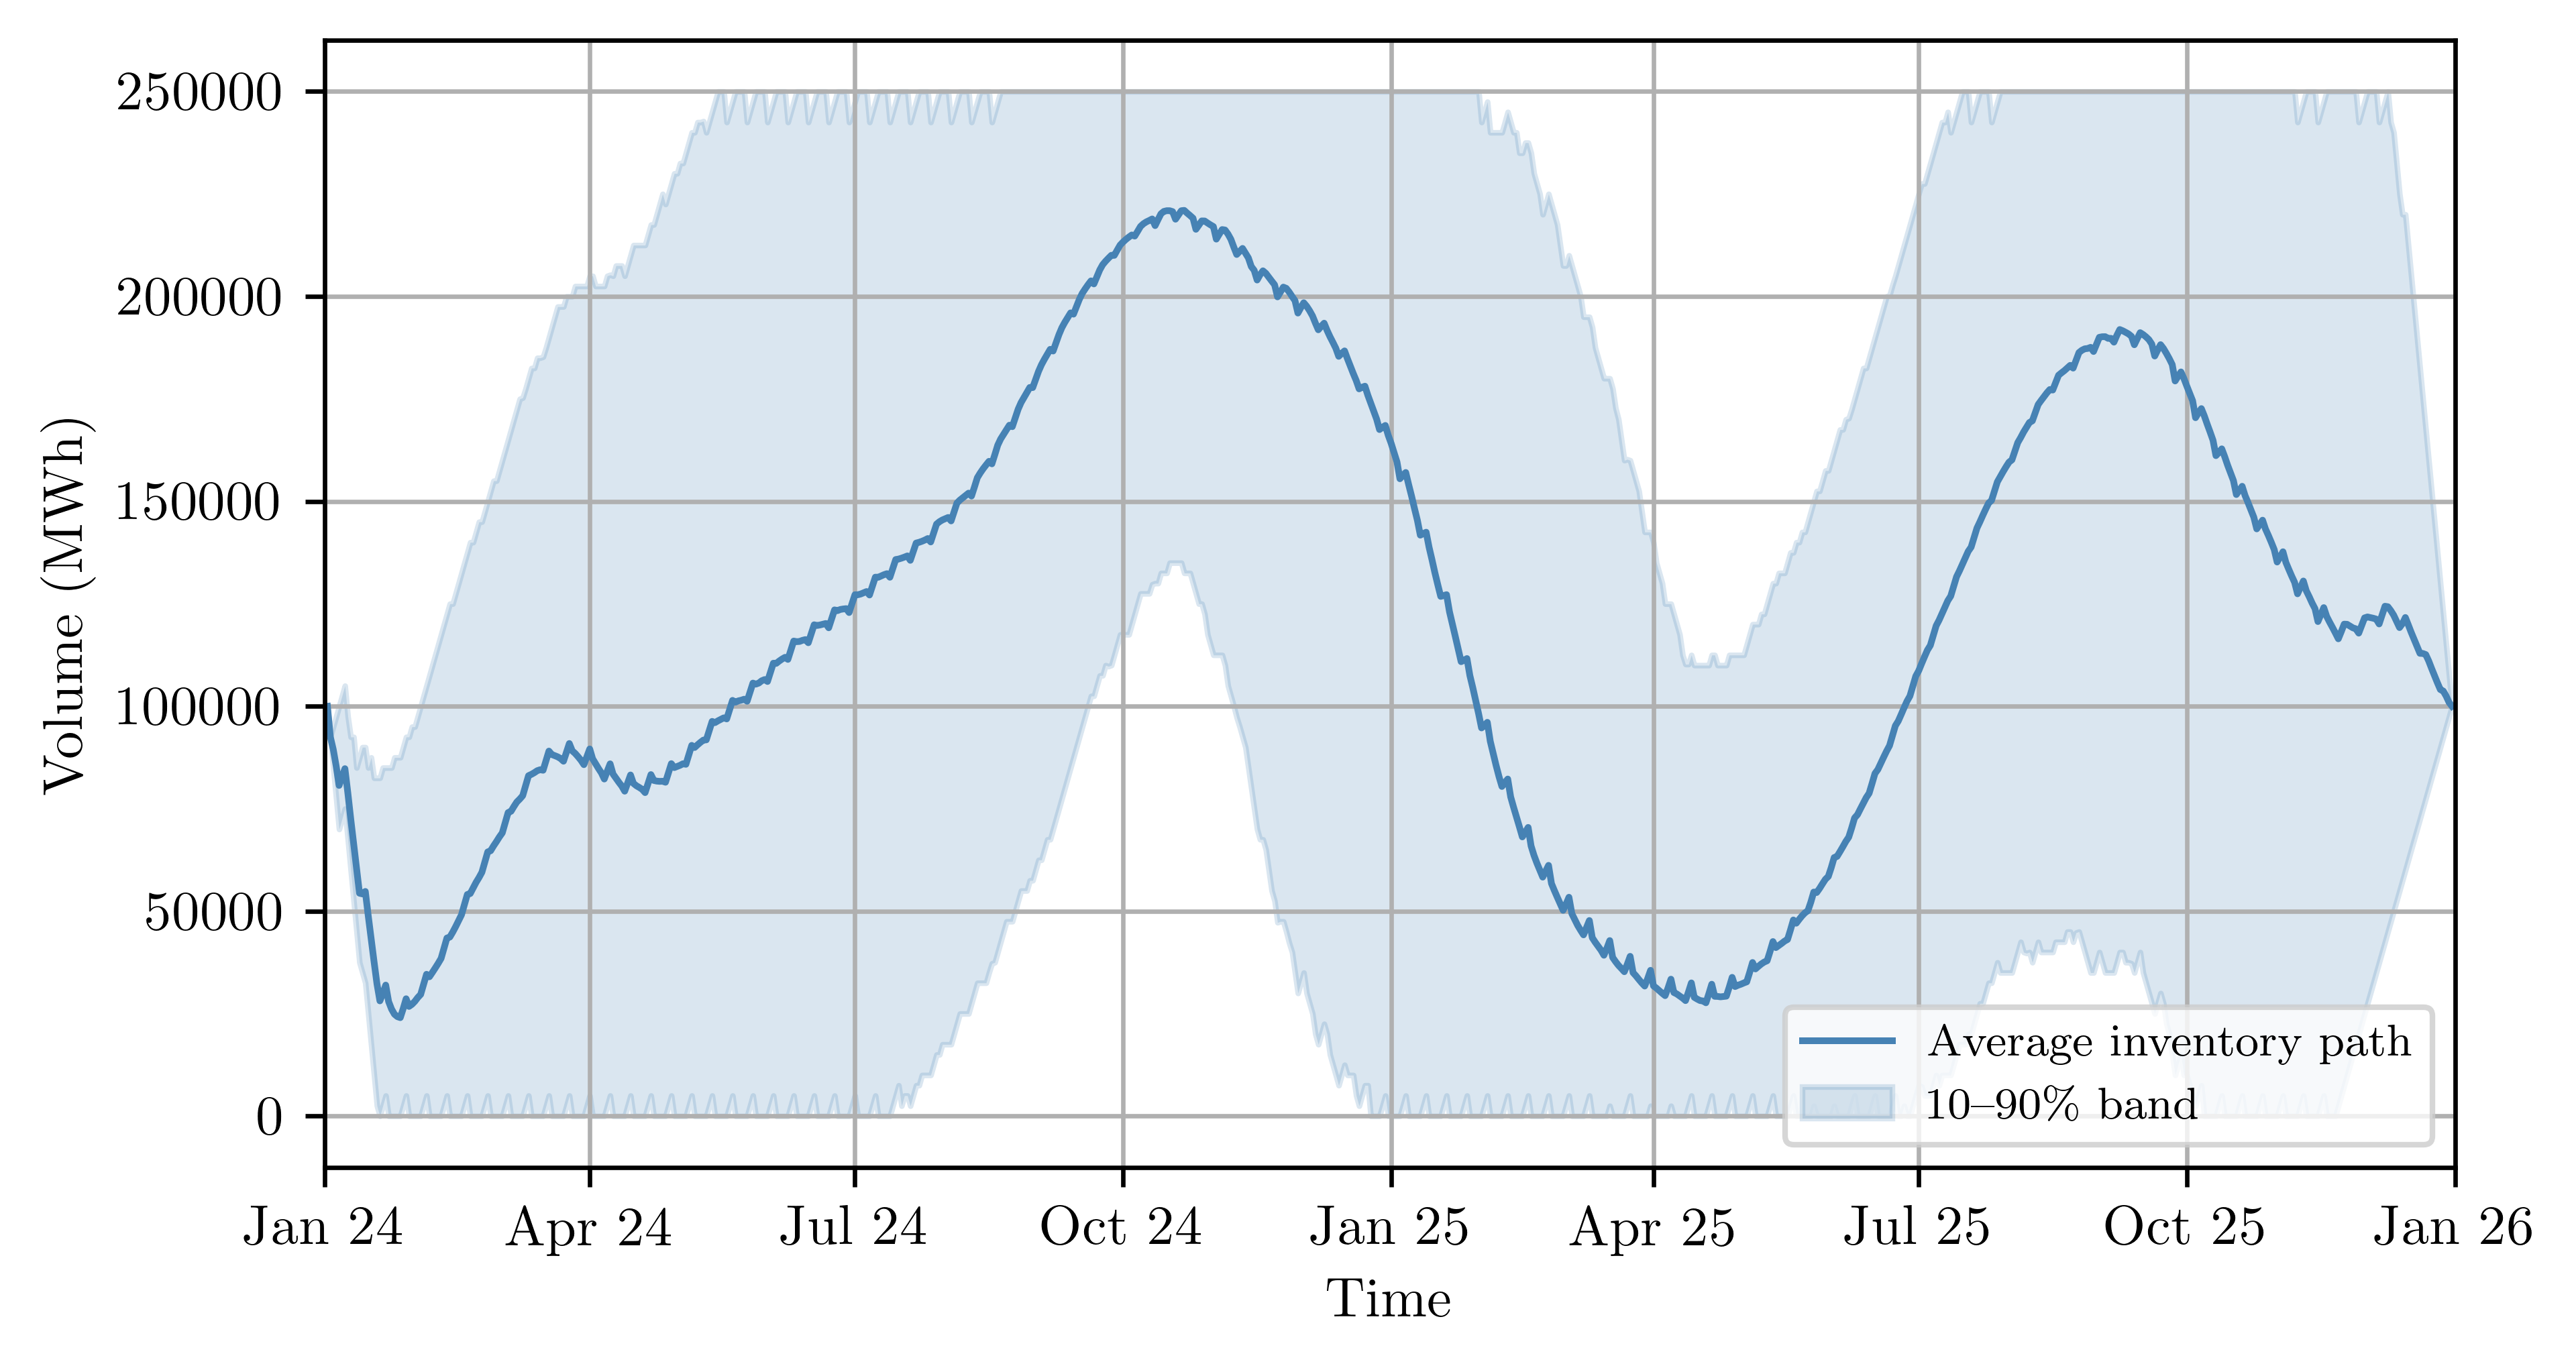

In [13]:
avg_path = v_path.mean(axis=1)
p10      = np.percentile(v_path, 10, axis=1)
p90      = np.percentile(v_path, 90, axis=1)

# Convert numpy datetime64 dates to pandas for plotting
dates_pd = pd.DatetimeIndex(dates)

x_start = pd.Timestamp("2024-01-01")
x_end   = pd.Timestamp("2026-01-01")


# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Inventory paths
ax.plot(dates_pd, avg_path, color="steelblue", lw=1.2,
        label="Average inventory path")
ax.fill_between(dates_pd, p10, p90, alpha=0.2, color="steelblue",
                label=r"10--90\% band")

# vmax is a true step function — plot on dense grid so steps fall on correct dates
# ax.step(dense_dates, vmax_dense, where="post", color="firebrick",
        # lw=0.9, ls="--", label=r"$v_{\max}(t)$")

# vmin should also be plotted on the daily calendar grid if enabled.
# ax.plot(dense_dates, vmin_dense, color="darkorange",
#         lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])



ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/spline_realised_paths.png")
plt.show()


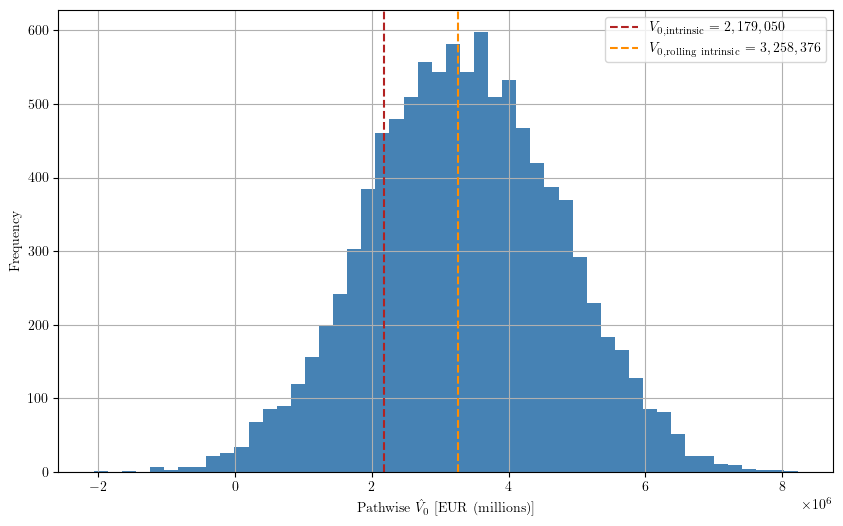

In [14]:
# Calculate V0_hat_pathwise for each path using v_path and S_sim
dv_path = np.diff(v_path, axis=0)            # inventory change from t to t+1
cashflow = -S_sim[:-1] * dv_path            # buy -> negative, sell -> positive

# Discount each calendar-day step back to time 0.
disc_to_0 = np.concatenate(([1.0], np.cumprod(disc_arr[:-1])))
V0_hat_pathwise = np.sum(disc_to_0[:, None] * cashflow, axis=0)

V0_intrinsic =   2179050.15
V0_rolling_intrinsic =    3258376.15 

# Plot frequency of V0_hat_pathwise
plt.figure(figsize=(10, 6))
plt.hist(V0_hat_pathwise, bins=50, alpha=1, color = "steelblue")
plt.axvline(V0_intrinsic, color="firebrick", linestyle="--", label=fr"$V_{{0,\mathrm{{intrinsic}}}} = {V0_intrinsic:,.0f}$")
plt.axvline(V0_rolling_intrinsic, color="darkorange", linestyle="--", label=fr"$V_{{0,\mathrm{{rolling\ intrinsic}}}} = {V0_rolling_intrinsic:,.0f}$")
plt.xlabel("Pathwise $\\hat{V}_0$ [EUR (millions)]")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("../../fig/Plots/spline_V0_hat_pathwise_histogram.png")
plt.show()


In [15]:
# ============================================================
# Out-of-sample valuation using stored spline parameters
# ============================================================
def oos_value_from_spline_store(S_test: np.ndarray, spline_store: dict) -> float:
    """
    Evaluate V0 out-of-sample via forward simulation.

    The stored spline parameters come from a separate training run on S_train.
    Here we roll the trained policy forward on fresh test paths S_test without
    refitting, record the realised cashflows, and discount them back to t=0.
    """
    M = S_test.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    n_path_idx[0] = n0_f
    n_curr_forward = np.full(M, n0_f, dtype=np.int32)
    n_next_forward = np.empty(M, dtype=np.int32)

    for t in range(T):
        full_knots = None if np.isnan(spline_store["knot_store"][t, 0]) else spline_store["knot_store"][t]
        _, C_hat_coarse = evaluate_coarse_continuation(
            S_test[t], spline_store["poly_coef_store"][t], spline_store["spline_coef_store"][t],
            spline_store["fit_kind_store"][t], full_knots, spline_store["degree"]
        )
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, all_can_reach[t + 1], terminal_penalty)
        forward_step_numba(
            n_curr_forward, n_next_forward, S_test[t], C_hat_fine_buf,
            all_next_idx[t], all_dv_mat[t], all_K_len[t], terminal_penalty
        )
        n_path_idx[t + 1] = n_next_forward
        n_curr_forward, n_next_forward = n_next_forward, n_curr_forward

    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]
    cf = -S_test[:T] * dv_paths

    cum_disc = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])
    pv = np.sum(cf * cum_disc[:, None], axis=0)

    at_target = (n_path_idx[T] == nT_f)
    n_failed = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan

    return float(np.nanmean(pv))


# ============================================================
# Run: train on S_sim, evaluate out-of-sample on S_test
# ============================================================
seed_oos = seed + 1
rng_oos = np.random.default_rng(seed_oos)
n_half_oos = int(np.ceil(n_paths_max / 2))
Z_half_oos = rng_oos.standard_normal(size=(Tn - 1, n_half_oos))
Z_oos = np.concatenate([Z_half_oos, -Z_half_oos], axis=1)[:, :n_paths_max]
S_test = simulate_from_Z(Z_oos, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                         kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat_oos = oos_value_from_spline_store(S_test, spline_store)
print(f"V0_hat (out-of-sample) = {V0_hat_oos:,.2f}")


V0_hat (out-of-sample) = 3,342,186.93


In [7]:
# ============================================================
# Multi-seed in-sample / out-of-sample valuation summary
# ============================================================
seed_results = []
n_seed_runs = 10

for seed_run in range(seed, seed + n_seed_runs):
    rng_train = np.random.default_rng(seed_run)
    n_half_train = int(np.ceil(n_paths_max / 2))
    Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
    Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_paths_max]
    S_train = simulate_from_Z(Z_train, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                              kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

    V0_hat_is, _, _, spline_store_seed = lsmc_value_and_paths_given_S(S_train)

    rng_oos_seed = np.random.default_rng(seed_run + 10_000)
    n_half_oos_seed = int(np.ceil(n_paths_max / 2))
    Z_half_oos_seed = rng_oos_seed.standard_normal(size=(Tn - 1, n_half_oos_seed))
    Z_oos_seed = np.concatenate([Z_half_oos_seed, -Z_half_oos_seed], axis=1)[:, :n_paths_max]
    S_oos_seed = simulate_from_Z(Z_oos_seed, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                                 kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

    V0_hat_oos_seed = oos_value_from_spline_store(S_oos_seed, spline_store_seed)

    seed_results.append({
        "seed": seed_run,
        "V0_hat_IS": V0_hat_is,
        "V0_hat_OOS": V0_hat_oos_seed,
    })

valuation_seed_df = pd.DataFrame(seed_results)
valuation_seed_df["IS_minus_OOS"] = valuation_seed_df["V0_hat_IS"] - valuation_seed_df["V0_hat_OOS"]
display(valuation_seed_df)


Backward pass: 100%|██████████| 729/729 [00:05<00:00, 121.74it/s]


,seed,V0_hat_IS,V0_hat_OOS,IS_minus_OOS
0,123,3.347084e+06,3.336983e+06,10101.243760
1,124,3.352964e+06,3.335776e+06,17187.758047
2,125,3.360261e+06,3.337466e+06,22795.460324
3,126,3.340749e+06,3.317579e+06,23170.352099
4,127,3.363008e+06,3.335794e+06,27214.419680
5,128,3.344877e+06,3.343658e+06,1218.918456
6,129,3.343601e+06,3.332822e+06,10778.520667
7,130,3.372357e+06,3.347689e+06,24667.826096
8,131,3.366785e+06,3.355735e+06,11050.162504
9,132,3.349544e+06,3.353194e+06,-3650.405683


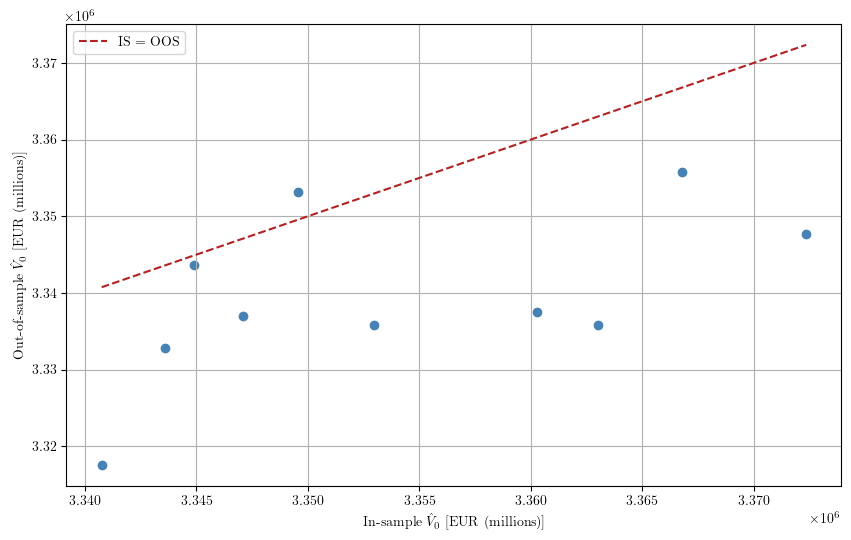

In [8]:
# plot IS vs OOS values across seeds
plt.figure(figsize=(10, 6))
plt.scatter(valuation_seed_df["V0_hat_IS"], valuation_seed_df["V0_hat_OOS"], color="steelblue")
plt.plot([valuation_seed_df["V0_hat_IS"].min(), valuation_seed_df["V0_hat_IS"].max()],
         [valuation_seed_df["V0_hat_IS"].min(), valuation_seed_df["V0_hat_IS"].max()],
         color="firebrick", linestyle="--", label="IS = OOS")
plt.xlabel("In-sample $\\hat{V}_0$ [EUR (millions)]")
plt.ylabel("Out-of-sample $\\hat{V}_0$ [EUR (millions)]")
plt.legend()
plt.grid()
plt.show()

Running 20 combos on 10 workers …


(n_obs, degree): 100%|██████████| 20/20 [00:17<00:00,  1.12it/s]


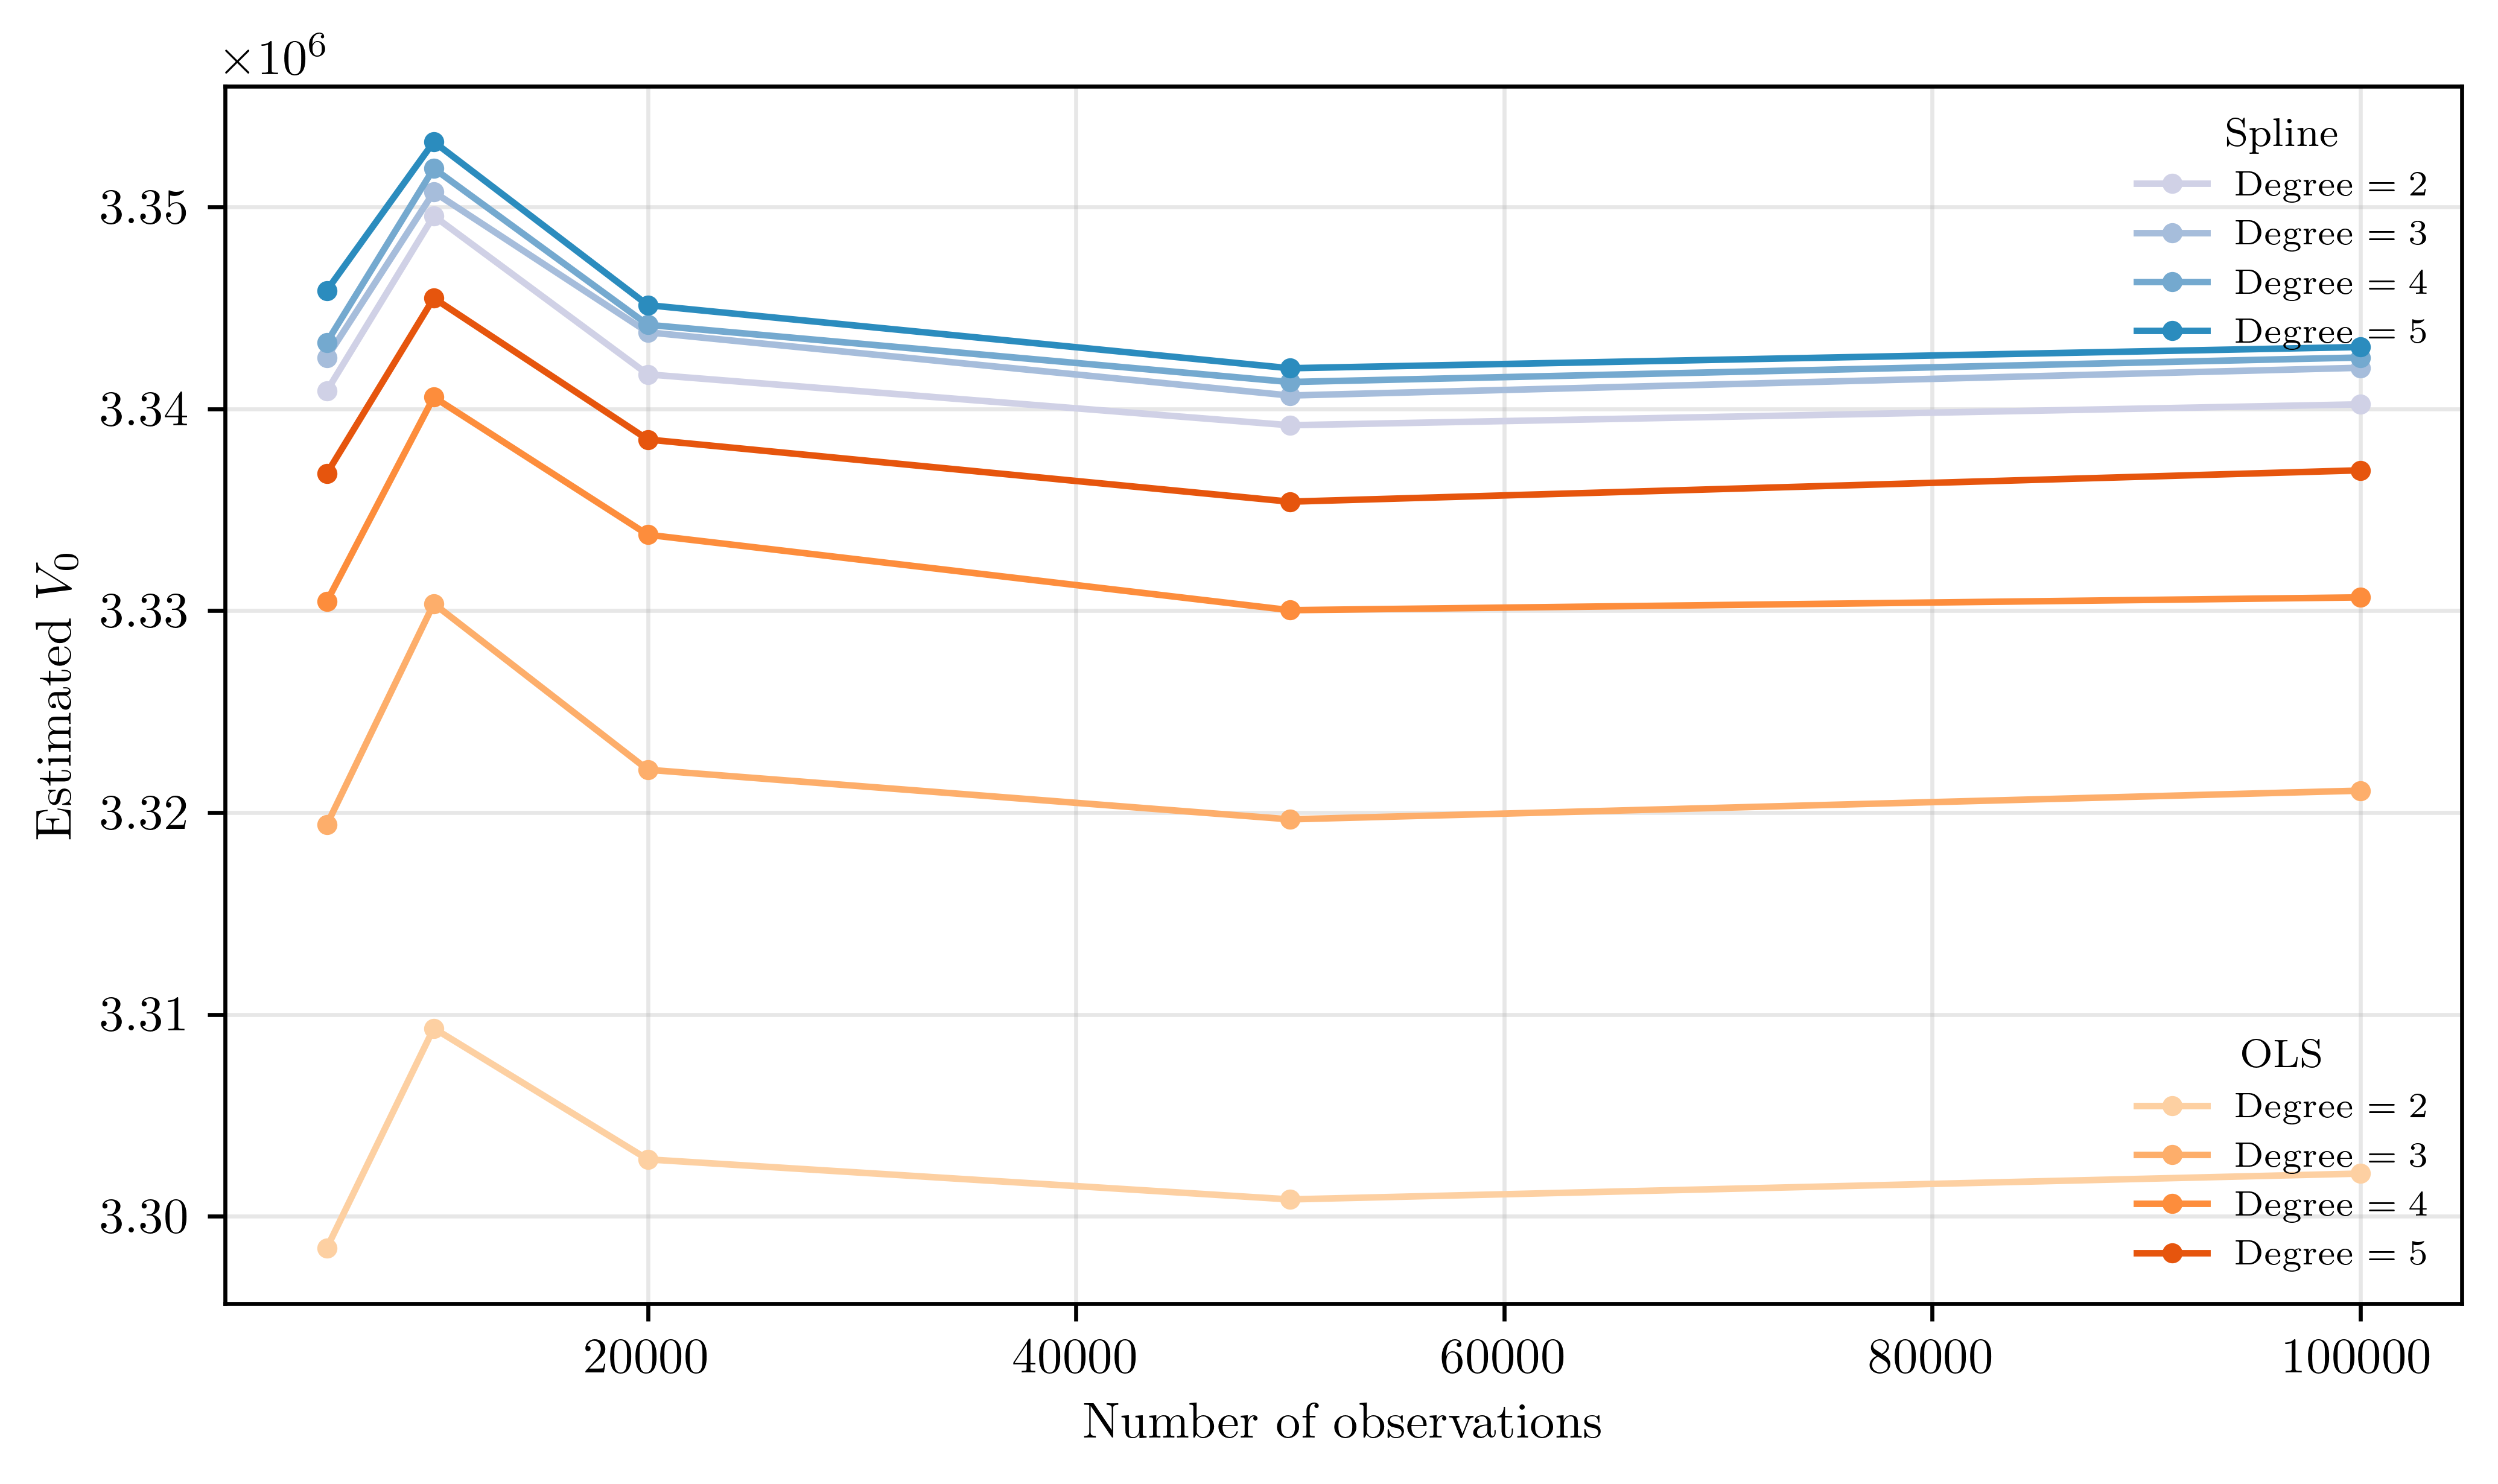

In [2]:
# -------------------------------------------------
# Convergence analysis: observations by basis degree (OLS vs spline)
# Standalone after the first notebook cell
# -------------------------------------------------
import os
import time
from joblib import Parallel, delayed

n_observations_values = [5000, 10000, 20000, 50000, 100000]
n_observations_max = max(n_observations_values)
basis_degree_values = [2, 3, 4, 5]
seed = 123

csv_path = "../data/OLS_vs_spline_convergence_observations_by_degree_single_seed.csv"


def build_ols_basis_matrix(S_t: np.ndarray, basis_degree: int) -> np.ndarray:
    return np.vander(np.asarray(S_t, dtype=np.float64), N=basis_degree + 1, increasing=True)


def build_poly_design_matrix_local(x: np.ndarray, poly_degree: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return np.vander(x, N=poly_degree + 1, increasing=True)


def fit_spline_coarse_local(
    X_poly,
    X_spline,
    Y_disc,
    reach_next,
    coarse_fine_idx,
    spline_coef_t,
    poly_coef_t,
    fit_kind_t,
):
    n_basis = spline_coef_t.shape[0]
    poly_dim = poly_coef_t.shape[0]
    use_spline = X_spline is not None
    Nc_loc = coarse_fine_idx.size

    XtX_spline = np.empty((n_basis, n_basis), dtype=np.float64)
    XtY_spline = np.empty(n_basis, dtype=np.float64)
    XtX_poly = np.empty((poly_dim, poly_dim), dtype=np.float64)
    XtY_poly = np.empty(poly_dim, dtype=np.float64)

    min_poly_obs = poly_dim
    min_spline_obs = n_basis

    for j in range(Nc_loc):
        if not reach_next[coarse_fine_idx[j]]:
            continue
        y = Y_disc[:, j]
        cnt = int(np.isfinite(y).sum())
        if cnt < min_poly_obs:
            continue

        if use_spline and cnt >= min_spline_obs:
            try:
                accumulate_normal_eq_finite(X_spline, y, XtX_spline, XtY_spline)
                spline_coef_t[:, j] = np.linalg.solve(XtX_spline, XtY_spline)
                fit_kind_t[j] = 1
                continue
            except np.linalg.LinAlgError:
                pass

        try:
            accumulate_normal_eq_finite(X_poly, y, XtX_poly, XtY_poly)
            poly_coef_t[:, j] = np.linalg.solve(XtX_poly, XtY_poly)
            fit_kind_t[j] = 0
        except np.linalg.LinAlgError:
            try:
                mask = np.isfinite(y)
                poly_coef_t[:, j] = np.linalg.lstsq(X_poly[mask], y[mask], rcond=None)[0]
                fit_kind_t[j] = 0
            except np.linalg.LinAlgError:
                continue


def ols_lsmc_value_given_S(S: np.ndarray, basis_degree: int) -> float:
    T_loc = S.shape[0] - 1
    M = S.shape[1]
    p_dim = basis_degree + 1

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current = np.empty((M, Nf), dtype=np.float64)
    pi_dtype = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T_loc, M), dtype=pi_dtype)
    n_curr = np.full(M, nT_f, dtype=np.int32)

    for t in range(T_loc - 1, -1, -1):
        S_t = S[t].astype(np.float64, copy=False)
        X = build_ols_basis_matrix(S_t, basis_degree=basis_degree)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        B = np.zeros((p_dim, Nc), dtype=np.float64)

        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            col = Y_disc[:, j]
            mask = np.isfinite(col)
            if mask.sum() < p_dim:
                continue
            Xm = X[mask]
            ym = col[mask]
            XtX = Xm.T @ Xm
            XtY = Xm.T @ ym
            try:
                B[:, j] = np.linalg.solve(XtX, XtY)
            except np.linalg.LinAlgError:
                B[:, j] = np.linalg.lstsq(Xm, ym, rcond=None)[0]

        C_hat_coarse = X @ B
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    return float(np.mean(Y_next[:, n0_f]))


def spline_lsmc_value_given_S(S: np.ndarray, basis_degree_local: int) -> float:
    T_loc = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current = np.empty((M, Nf), dtype=np.float64)
    pi_dtype = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T_loc, M), dtype=pi_dtype)
    n_curr = np.full(M, nT_f, dtype=np.int32)

    poly_dim = basis_degree_local + 1
    spline_dim = n_spline_internal_knots + basis_degree_local + 1

    for t in range(T_loc - 1, -1, -1):
        S_t = S[t].astype(np.float64, copy=False)
        X_poly = build_poly_design_matrix_local(S_t, poly_degree=basis_degree_local)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        full_knots = build_spline_knots_from_S(S_t, n_spline_internal_knots, basis_degree_local)
        X_spline = None if full_knots is None else build_bspline_design_matrix(S_t, full_knots, basis_degree_local)

        spline_coef_t = np.zeros((spline_dim, Nc), dtype=np.float64)
        poly_coef_t = np.zeros((poly_dim, Nc), dtype=np.float64)
        fit_kind_t = np.zeros(Nc, dtype=np.int8)

        fit_spline_coarse_local(
            X_poly, X_spline, Y_disc, reach_next, coarse_fine_idx,
            spline_coef_t, poly_coef_t, fit_kind_t,
        )

        C_hat_coarse = X_poly @ poly_coef_t
        spline_cols = fit_kind_t == 1
        if X_spline is not None and np.any(spline_cols):
            C_hat_coarse[:, spline_cols] = X_spline @ spline_coef_t[:, spline_cols]

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    return float(np.mean(Y_next[:, n0_f]))


def _eval_obs_degree_combo(n_obs: int, deg: int, Z_full: np.ndarray) -> dict:
    try:
        nb.set_num_threads(1)
    except Exception:
        pass

    S = simulate_from_Z(
        Z_full, n_paths=n_obs, Tn=Tn, t_arr=t_arr,
        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col,
    )

    t0 = time.perf_counter()
    V0_hat_ols = ols_lsmc_value_given_S(S, basis_degree=deg)
    runtime_ols_seconds = time.perf_counter() - t0

    t1 = time.perf_counter()
    V0_hat_spline = spline_lsmc_value_given_S(S, basis_degree_local=deg)
    runtime_spline_seconds = time.perf_counter() - t1

    return {
        "seed": int(seed),
        "n_observations": int(n_obs),
        "basis_degree": int(deg),
        "n_spline_internal_knots": int(n_spline_internal_knots),
        "V0_hat_OLS": V0_hat_ols,
        "V0_hat_spline": V0_hat_spline,
        "runtime_OLS_seconds": runtime_ols_seconds,
        "runtime_spline_seconds": runtime_spline_seconds,
    }


rng = np.random.default_rng(seed)
n_half = int(np.ceil(n_observations_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_observations_max]

combos = [(n_obs, deg) for n_obs in n_observations_values for deg in basis_degree_values]
n_jobs = min(os.cpu_count(), len(combos))

print(f"Running {len(combos)} combos on {n_jobs} workers …")
records = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(_eval_obs_degree_combo)(n_obs, deg, Z)
    for n_obs, deg in tqdm(combos, desc="(n_obs, degree)")
)

results_df = pd.DataFrame(records)
results_df = results_df.sort_values(["basis_degree", "n_observations"]).reset_index(drop=True)
results_df.to_csv(csv_path, index=False)

ols_palette = ["#fdd0a2", "#fdae6b", "#fd8d3c", "#e6550d", "#a63603"]
spline_palette = ["#d0d1e6", "#a6bddb", "#74a9cf", "#2b8cbe", "#045a8d"]
ols_colors = dict(zip(basis_degree_values, ols_palette))
spline_colors = dict(zip(basis_degree_values, spline_palette))

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=600)
ols_handles = []
spline_handles = []

for basis_degree_local in basis_degree_values:
    df_plot = results_df.loc[results_df["basis_degree"] == basis_degree_local].sort_values("n_observations")
    obs_array = df_plot["n_observations"].to_numpy(dtype=np.float64)

    ols_line, = ax.plot(
        obs_array,
        df_plot["V0_hat_OLS"].to_numpy(dtype=np.float64),
        linewidth=1.3,
        color=ols_colors[basis_degree_local],
        marker="o",
        markersize=3.0,
        label=rf"Degree $={basis_degree_local}$",
    )
    spline_line, = ax.plot(
        obs_array,
        df_plot["V0_hat_spline"].to_numpy(dtype=np.float64),
        linewidth=1.3,
        color=spline_colors[basis_degree_local],
        marker="o",
        markersize=3.0,
        label=rf"Degree $={basis_degree_local}$",
    )
    ols_handles.append(ols_line)
    spline_handles.append(spline_line)

ax.set_xlabel("Number of observations")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True, alpha=0.3)
legend_ols = ax.legend(
    handles=ols_handles,
    labels=[rf"Degree $={degree}$" for degree in basis_degree_values],
    title="OLS",
    loc="lower right",
    fontsize=7,
    title_fontsize=8,
    frameon=False,
)
ax.add_artist(legend_ols)
ax.legend(
    handles=spline_handles,
    labels=[rf"Degree $={degree}$" for degree in basis_degree_values],
    title="Spline",
    loc="upper right",
    fontsize=7,
    title_fontsize=8,
    frameon=False,
)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_vs_spline_convergence_observations_by_degree_single_seed.png")
plt.show()


Running 100 IS+OOS combos on 10 workers …


(degree, knots): 100%|██████████| 100/100 [04:16<00:00,  2.57s/it]


Saved to ../data/spline_v0_degree_knots_is_oos_grid.csv


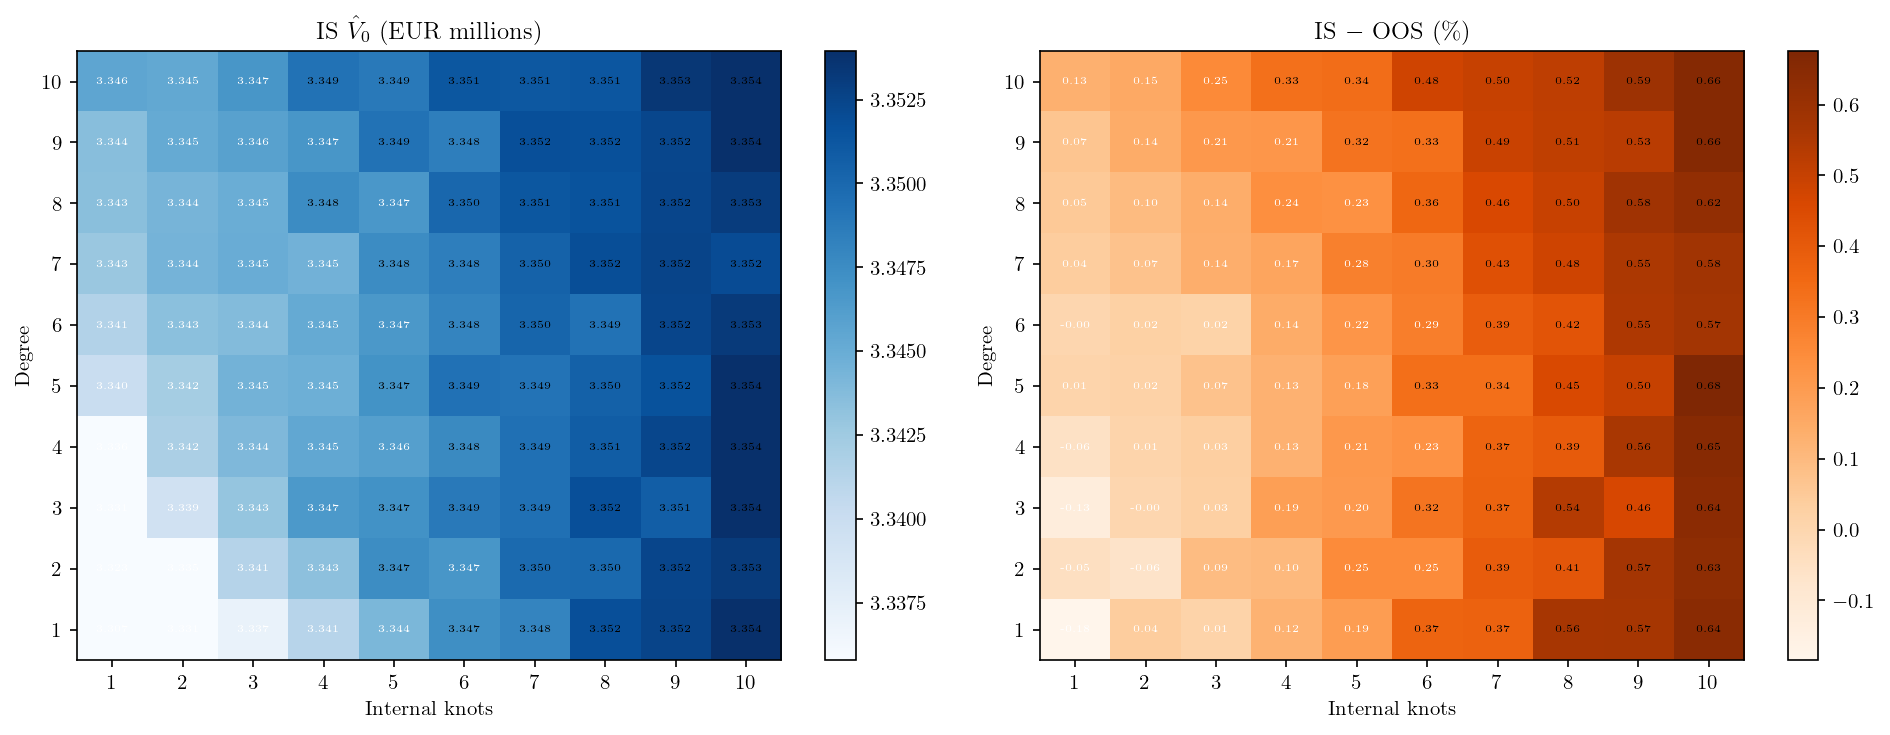


IS - OOS (%) grid:
[[-0.184  0.039  0.011  0.123  0.193  0.37   0.374  0.562  0.567  0.643]
 [-0.045 -0.064  0.091  0.104  0.252  0.25   0.391  0.411  0.568  0.63 ]
 [-0.129 -0.002  0.03   0.187  0.203  0.318  0.37   0.538  0.463  0.642]
 [-0.057  0.009  0.032  0.127  0.208  0.227  0.369  0.394  0.56   0.649]
 [ 0.009  0.021  0.073  0.126  0.185  0.333  0.335  0.455  0.499  0.676]
 [-0.001  0.025  0.016  0.144  0.218  0.287  0.389  0.418  0.548  0.572]
 [ 0.041  0.074  0.137  0.166  0.284  0.296  0.43   0.483  0.551  0.58 ]
 [ 0.053  0.097  0.14   0.238  0.232  0.357  0.459  0.496  0.582  0.621]
 [ 0.067  0.142  0.208  0.214  0.322  0.33   0.491  0.514  0.527  0.656]
 [ 0.131  0.153  0.255  0.332  0.339  0.478  0.498  0.516  0.591  0.656]]


In [2]:

# ============================================================
# IS + OOS valuation grid: degree in {1,..,10} x internal_knots in {0,..,9}
# Requires only cell 0 to have been run.
# ============================================================

import os
from joblib import Parallel, delayed

csv_path_grid = "../data/spline_v0_degree_knots_is_oos_grid.csv"

degree_values = list(range(1, 11))  # 1..10
knot_values   = list(range(1, 11))  # 1..10

# --- OOS paths (different seed from S_sim) ---
seed_oos_grid = seed + 9999
rng_oos_grid  = np.random.default_rng(seed_oos_grid)
n_half_oos_g  = int(np.ceil(n_paths_max / 2))
Z_half_oos_g  = rng_oos_grid.standard_normal(size=(Tn - 1, n_half_oos_g))
Z_oos_g       = np.concatenate([Z_half_oos_g, -Z_half_oos_g], axis=1)[:, :n_paths_max]
S_oos_grid    = simulate_from_Z(Z_oos_g, n_paths=n_paths_max, Tn=Tn,
                                 t_arr=t_arr, kappa_hat=kappa_hat,
                                 sigma_hat=sigma_hat, m_col=m_col)


# --- Helpers ---

def _poly_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    return np.vander(np.asarray(x, dtype=np.float64), N=degree + 1, increasing=True)


def _fit_coarse(X_poly, X_spline, Y_disc, reach_next, coarse_fine_idx,
                spline_coef_t, poly_coef_t, fit_kind_t):
    poly_dim   = poly_coef_t.shape[0]
    n_basis    = spline_coef_t.shape[0]
    use_spline = X_spline is not None
    Nc_loc     = coarse_fine_idx.size

    XtX_sp = np.empty((n_basis, n_basis), dtype=np.float64)
    XtY_sp = np.empty(n_basis,            dtype=np.float64)
    XtX_po = np.empty((poly_dim, poly_dim), dtype=np.float64)
    XtY_po = np.empty(poly_dim,             dtype=np.float64)

    for j in range(Nc_loc):
        if not reach_next[coarse_fine_idx[j]]:
            continue
        y   = Y_disc[:, j]
        cnt = int(np.isfinite(y).sum())
        if cnt < poly_dim:
            continue
        if use_spline and cnt >= n_basis:
            try:
                accumulate_normal_eq_finite(X_spline, y, XtX_sp, XtY_sp)
                spline_coef_t[:, j] = np.linalg.solve(XtX_sp, XtY_sp)
                fit_kind_t[j] = 1
                continue
            except np.linalg.LinAlgError:
                pass
        try:
            accumulate_normal_eq_finite(X_poly, y, XtX_po, XtY_po)
            poly_coef_t[:, j] = np.linalg.solve(XtX_po, XtY_po)
            fit_kind_t[j] = 0
        except np.linalg.LinAlgError:
            try:
                mask = np.isfinite(y)
                poly_coef_t[:, j] = np.linalg.lstsq(X_poly[mask], y[mask], rcond=None)[0]
                fit_kind_t[j] = 0
            except np.linalg.LinAlgError:
                pass


def _eval_stored_C(S_t, poly_coef, spline_coef, fit_kind, full_knots, degree):
    X_poly       = _poly_matrix(S_t, degree)
    C_hat_coarse = X_poly @ poly_coef
    spline_cols  = fit_kind == 1
    if full_knots is not None and np.any(spline_cols):
        X_sp = build_bspline_design_matrix(S_t, full_knots, degree)
        C_hat_coarse[:, spline_cols] = X_sp @ spline_coef[:, spline_cols]
    return C_hat_coarse


def _oos_rollout(S_test, knot_store, spline_coef_store, poly_coef_store,
                 fit_kind_store, degree):
    T_loc = S_test.shape[0] - 1
    M     = S_test.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_curr      = np.full(M, n0_f, dtype=np.int32)
    n_next      = np.empty(M, dtype=np.int32)
    n_path_last = np.full(M, n0_f, dtype=np.int32)
    dv_paths    = np.empty((T_loc, M), dtype=np.float64)

    for t in range(T_loc):
        full_knots   = None if np.isnan(knot_store[t, 0]) else knot_store[t]
        C_hat_coarse = _eval_stored_C(S_test[t], poly_coef_store[t], spline_coef_store[t],
                                      fit_kind_store[t], full_knots, degree)
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, all_can_reach[t + 1], terminal_penalty)
        forward_step_numba(n_curr, n_next, S_test[t], C_hat_fine_buf,
                           all_next_idx[t], all_dv_mat[t], all_K_len[t], terminal_penalty)
        dv_paths[t] = v_fine[n_next] - v_fine[n_curr]
        n_path_last = n_next.copy()
        n_curr, n_next = n_next, n_curr

    cf       = -S_test[:T_loc] * dv_paths
    cum_disc = np.ones(T_loc, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:T_loc - 1])
    pv = np.sum(cf * cum_disc[:, None], axis=0)

    at_target = (n_path_last == nT_f)
    if int(np.sum(~at_target)) > 0:
        print(f"    OOS: {int(np.sum(~at_target))}/{M} paths missed terminal target.")
    pv[~at_target] = np.nan
    return float(np.nanmean(pv))


def _eval_combo_oos(deg: int, nk: int, S_train: np.ndarray, S_test: np.ndarray):
    """Backward pass on S_train → IS value + OOS rollout on S_test."""
    try:
        nb.set_num_threads(1)
    except Exception:
        pass

    T_loc      = S_train.shape[0] - 1
    M          = S_train.shape[1]
    poly_dim   = deg + 1
    spline_dim = nk + deg + 1
    knot_dim   = nk + 2 * (deg + 1)

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv     = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty
    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T_loc, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    knot_store        = np.full((T_loc, knot_dim), np.nan, dtype=np.float64)
    spline_coef_store = np.zeros((T_loc, spline_dim, Nc), dtype=np.float64)
    poly_coef_store   = np.zeros((T_loc, poly_dim,   Nc), dtype=np.float64)
    fit_kind_store    = np.zeros((T_loc, Nc), dtype=np.int8)

    for t in range(T_loc - 1, -1, -1):
        S_t        = S_train[t].astype(np.float64, copy=False)
        X_poly     = _poly_matrix(S_t, deg)
        reach_next = all_can_reach[t + 1]
        Y_disc     = disc_arr[t] * Y_next[:, coarse_fine_idx]

        full_knots = build_spline_knots_from_S(S_t, nk, deg) if nk >= 1 else None
        if full_knots is not None:
            knot_store[t] = full_knots
        X_spline = None if full_knots is None else build_bspline_design_matrix(S_t, full_knots, deg)

        _fit_coarse(X_poly, X_spline, Y_disc, reach_next, coarse_fine_idx,
                    spline_coef_store[t], poly_coef_store[t], fit_kind_store[t])

        C_hat_coarse = X_poly @ poly_coef_store[t]
        spline_cols  = fit_kind_store[t] == 1
        if X_spline is not None and np.any(spline_cols):
            C_hat_coarse[:, spline_cols] = X_spline @ spline_coef_store[t][:, spline_cols]

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)
        bellman_update_numba(Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
                             C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
                             disc_arr[t], terminal_penalty)
        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    v0_is  = float(np.mean(Y_next[:, n0_f]))
    v0_oos = _oos_rollout(S_test, knot_store, spline_coef_store,
                          poly_coef_store, fit_kind_store, deg)
    return deg, nk, v0_is, v0_oos


# --- Parallel sweep ---
combos = [(deg, nk) for deg in degree_values for nk in knot_values]
n_jobs = min(os.cpu_count(), len(combos))

print(f"Running {len(combos)} IS+OOS combos on {n_jobs} workers …")
results_raw = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(_eval_combo_oos)(deg, nk, S_sim, S_oos_grid)
    for deg, nk in tqdm(combos, desc="(degree, knots)")
)

# --- Reconstruct grids ---
V0_IS_grid  = np.full((len(degree_values), len(knot_values)), np.nan)
V0_OOS_grid = np.full((len(degree_values), len(knot_values)), np.nan)

for deg, nk, v0_is, v0_oos in results_raw:
    i = degree_values.index(deg)
    j = knot_values.index(nk)
    V0_IS_grid[i, j]  = v0_is
    V0_OOS_grid[i, j] = v0_oos

pct_diff_grid = (V0_IS_grid - V0_OOS_grid) / V0_OOS_grid * 100.0

# --- Save to CSV ---
results_grid_df = pd.DataFrame([
    {"degree": deg, "internal_knots": nk,
     "V0_hat_IS": v0_is, "V0_hat_OOS": v0_oos,
     "pct_diff": (v0_is - v0_oos) / v0_oos * 100.0 if np.isfinite(v0_oos) else np.nan}
    for deg, nk, v0_is, v0_oos in results_raw
]).sort_values(["degree", "internal_knots"]).reset_index(drop=True)
results_grid_df.to_csv(csv_path_grid, index=False)
print(f"Saved to {csv_path_grid}")

# --- Plot ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)


def _annotated_heatmap(ax, grid, title, fmt, cmap, vmin=None, vmax=None):
    vmid = np.nanmean(grid)
    im   = ax.imshow(grid, aspect="auto", cmap=cmap, origin="lower",
                     vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(knot_values)));   ax.set_xticklabels(knot_values)
    ax.set_yticks(range(len(degree_values))); ax.set_yticklabels(degree_values)
    ax.set_xlabel("Internal knots")
    ax.set_ylabel("Degree")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(len(degree_values)):
        for j in range(len(knot_values)):
            val = grid[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        fontsize=5, color="white" if val < vmid else "black")


# IS heatmap — clip to 5th-95th percentile so the low-degree/0-knot outlier
# doesn't wash out the rest of the colour scale
vlo_is = np.nanpercentile(V0_IS_grid / 1e6, 5)
vhi_is = np.nanpercentile(V0_IS_grid / 1e6, 95)
_annotated_heatmap(axes[0], V0_IS_grid / 1e6,
                   r"IS $\hat{V}_0$ (EUR millions)", ".3f",
                   cmap="Blues", vmin=vlo_is, vmax=vhi_is)

# IS - OOS (%) heatmap — full range, no clipping
_annotated_heatmap(axes[1], pct_diff_grid,
                   r"IS $-$ OOS (\%)", ".2f",
                   cmap="Oranges")

fig.tight_layout()
plt.savefig("../../fig/Plots/spline_v0_is_oos_degree_knots.png")
plt.show()

print("\nIS - OOS (%) grid:")
print(np.round(pct_diff_grid, 3))


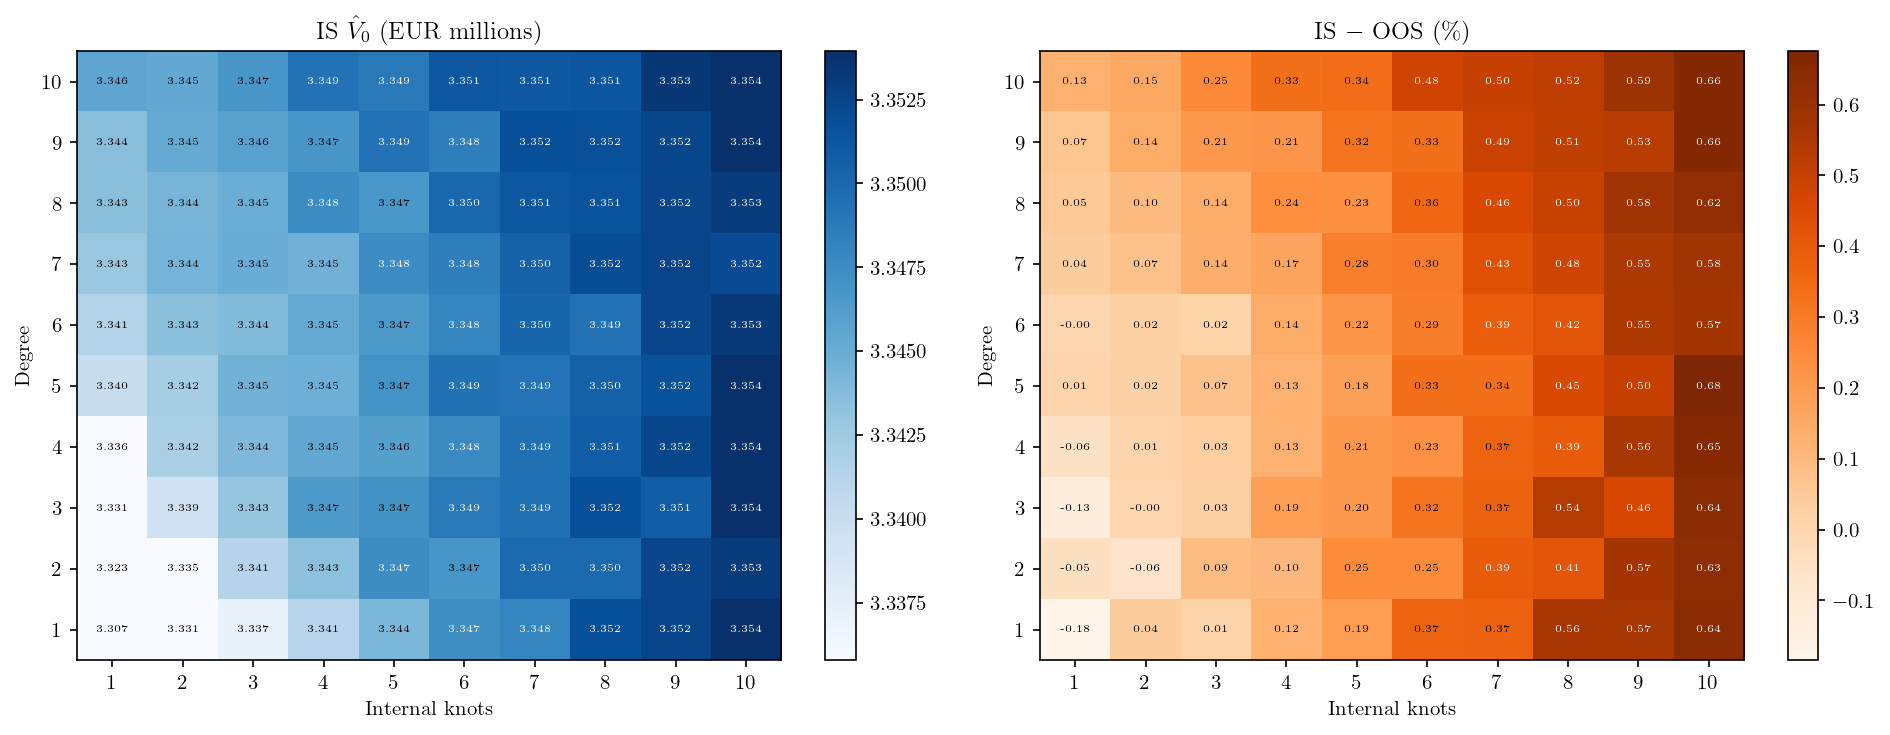

In [4]:

import matplotlib.colors as mcolors

def _annotated_heatmap_fixed(ax, grid, title, fmt, cmap, vmin=None, vmax=None):
    im = ax.imshow(grid, aspect="auto", cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(knot_values)));   ax.set_xticklabels(knot_values)
    ax.set_yticks(range(len(degree_values))); ax.set_yticklabels(degree_values)
    ax.set_xlabel("Internal knots")
    ax.set_ylabel("Degree")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    norm = mcolors.Normalize(vmin=im.norm.vmin, vmax=im.norm.vmax)
    cmap_obj = plt.get_cmap(cmap)
    for i in range(len(degree_values)):
        for j in range(len(knot_values)):
            val = grid[i, j]
            if np.isfinite(val):
                rgba = cmap_obj(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                color = "white" if luminance < 0.5 else "black"
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        fontsize=5, color=color)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

vlo_is = np.nanpercentile(V0_IS_grid / 1e6, 5)
vhi_is = np.nanpercentile(V0_IS_grid / 1e6, 95)
_annotated_heatmap_fixed(axes[0], V0_IS_grid / 1e6,
                         r"IS $\hat{V}_0$ (EUR millions)", ".3f",
                         cmap="Blues", vmin=vlo_is, vmax=vhi_is)
_annotated_heatmap_fixed(axes[1], pct_diff_grid,
                         r"IS $-$ OOS (\%)", ".2f",
                         cmap="Oranges")

fig.tight_layout()
plt.savefig("../../fig/Plots/spline_v0_is_oos_degree_knots.png")
plt.show()
